# DTLZ4 Results

In [ ]:
import multiprocessing
from functools import partial
from meamt_core import build_toolbox, gen_inicial_tables, run, generate_dtlz3_front_random
from deap import benchmarks

# 1. Parâmetros
K = 10
NPOP = 800
NGEN = 300
NOBJ = 4 
IND_SIZE = NOBJ + K - 1 
NUM_TABLES = int((1 << NOBJ)) 
MAX_TABLE_SIZE = int(NPOP / NUM_TABLES)
REF_POINT_HV = [1.1]*NOBJ

# 2. Configurando o Toolbox de forma segura para o multiprocessing
# O 'partial' "congela" o argumento obj=NOBJ na função nativa do DEAP
func_dtlz4_segura = partial(benchmarks.dtlz4, obj=NOBJ, alpha=100)
toolbox = build_toolbox(func_dtlz4_segura, IND_SIZE, NPOP, NOBJ)

# =======================================================
# A TRAVA DE SEGURANÇA (OBRIGATÓRIA NO JUPYTER/WINDOWS)
# =======================================================
if __name__ == '__main__':
    # Cria o pool apenas se for o processo principal
    num_cores = multiprocessing.cpu_count() - 1 
    pool = multiprocessing.Pool(processes=num_cores)
    toolbox.register("map", pool.map) 

    # 3. Inicialização
    pop_inicial = toolbox.population()
    
    # Avaliação inicial
    fitnesses = toolbox.map(toolbox.evaluate, pop_inicial)
    for ind, fit in zip(pop_inicial, fitnesses):
        ind.fitness.values = fit

    tabelas = gen_inicial_tables(pop_inicial, NUM_TABLES, MAX_TABLE_SIZE, NOBJ)
    pareto_real = generate_dtlz3_front_random(NOBJ, 1000)
    reset = 20
    print(f"Iniciando evolução usando {num_cores} threads...")

    # 4. Executando o MEAMT
    logbook = run(tabelas, pareto_real, NUM_TABLES, MAX_TABLE_SIZE, NGEN, toolbox, 0.9, 1.0, REF_POINT_HV, NOBJ, reset)

    # Fechando os processos corretamente
    pool.close()
    pool.join()

    print("Evolução concluída!")

Iniciando evolução usando 15 threads...
Evolução concluída!


(6.123233996695604e-17, 1.00000000015659, 0.0, 0.0)
(6.123234058990526e-17, 0.0, 0.0, 1.000000010330123)
(3.74939945709806e-33, 0.0, 6.12323399646092e-17, 1.0000000001182632)
(1.0000000008181498, 0.0, 0.0, 0.0)
(0.003133856112959485, 0.0, 1.819385319983476, 0.0)
(2.2958450218482463e-49, 3.7493994569645766e-33, 6.123233996242924e-17, 1.0000000000826619)
(5.855374592398676e-17, 2.2453946831569042e-17, 1.4014847399990715e-202, 1.0241550398365196)
(0.5731956417979502, 0.11821911843152513, 0.8159072305224296, 0.029769214266009262)
(0.6750947859901196, 0.3091922697698512, 0.6415696012835181, 0.21659054068860037)
(0.8775362165979361, 0.2848872026739959, 0.1578422410558391, 0.3560809678332124)
(0.8267417987575496, 0.378646345041091, 0.36859912956423785, 0.21800931259467976)
(0.10301917578204059, 0.4734073545002621, 0.09903972802229662, 0.8714468211770765)
(0.6921470524579387, 0.0, 0.9828903210039411, 0.10160871136830793)
(0.10365682915646973, 0.20071330622003394, 0.9294399596129034, 0.29173753

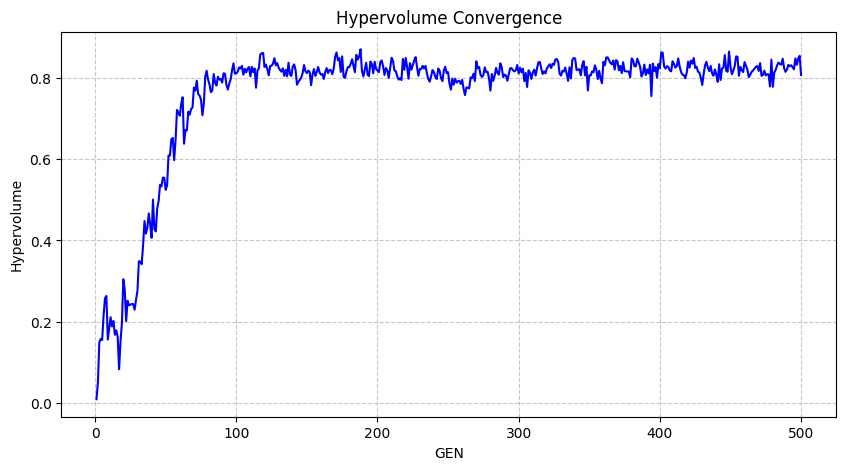

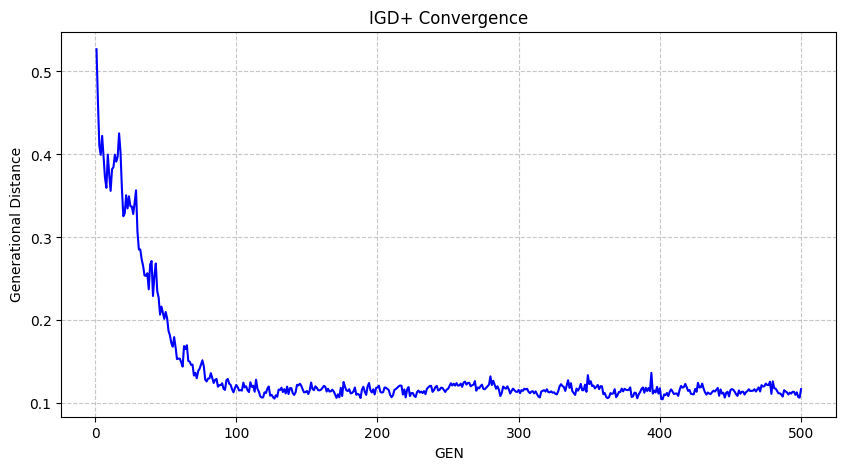

In [4]:
import matplotlib.pyplot as plt
# 3D Graphic of final pareto front
for ind in tabelas[0]:
    print(ind.fitness.values)
# Hypervolume Graphic
gen = logbook.select("gen")
fit_hv = logbook.select("hypervolume")
plt.figure(figsize=(10, 5))
plt.plot(gen, fit_hv, 'b-')
plt.title("Hypervolume Convergence")
plt.xlabel('GEN')
plt.ylabel('Hypervolume')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# IGD+ Graphic
gen = logbook.select("gen")
fit_igd = logbook.select("igd_plus")
plt.figure(figsize=(10, 5))
plt.plot(gen, fit_igd, 'b-')
plt.title("IGD+ Convergence")
plt.xlabel('GEN')
plt.ylabel('Generational Distance')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()